# Which *sites* to mutate: greedy selection for a homo-oligomer

`labelizer_greedy_pipeline.ipynb` asks, for a monomer, which FRET pairs to
measure. A homo-oligomer asks a different question, and pretending it is the
monomer question quietly buys the wrong experiment.

In a homo-oligomer the labelling mix is **statistical**: every protomer is the
same sequence, so a cysteine put at site 1 exists on *all* protomers at once,
and donor and acceptor find every combination the chosen sites allow. Each
site is mutated **once** and the resulting pairs are free — a dimer labelled
at sites {1, 2} measures 1:1, 2:2, 1:2 *and* 2:1. So the thing worth choosing
is a **set of labelling sites**, and the thing worth evaluating is the **set of
pairs that set implies** — all combinations, not any single pair.

`IMP.bff.select_informative_sites` does exactly that, with Olga's criterion
(Dimura *et al.*, *Nat. Commun.* **11**, 5394, 2020) applied per *site*: each
greedy step scores a candidate site by the expected RMSD left by every pair
the enlarged site set would measure. `select_informative_pairs`, which adds
one pair per step, is the monomer case — there a pair is a double mutant and
pairs are the unit. Run on an oligomer it charges two mutations for the first
measurement; run here side by side, that difference is the whole point.

The case is T4 lysozyme again, assembled into a **synthetic C2 homodimer**
(protomer copy rotated by π, centres 52 Å apart): a toy assembly, chosen
deliberately — the grades, the labelizer scores and the machinery are all in
the tree, and the point being made is about the *unit of selection*, not about
this particular interface. The ensemble it must discriminate is 60 alternative
relative arrangements of the protomers, wobbling chain B by up to 18° and 2 Å
around the C2 reference.

In [1]:
%matplotlib inline
import json, pathlib, tempfile, time
import numpy as np
import pylab as plt

import IMP
import IMP.atom
import IMP.core
import IMP.bff as bff

root = bff.get_example_path("structure") + "/T4L/"
pdb = root + "/3GUN-processed.pdb"
ERR, R0, MIN_LS, MIN_SEP, N_SITES, N_FRAMES = 0.06, 52.0, 1.5, 10, 8, 60
rng = np.random.default_rng(7)

## 1. Labelable sites on the protomer

The Labelizer score is a property of the protomer alone — one copy of it is
all that needs scoring, which is the first way the oligomer is cheaper: the
dimer does not double this step. Sites are the usual filter from the pipeline
notebook: combined score ≥ 1.5, at least 10 residues apart, the best
`N_SITES` of what survives.

In [2]:
grades_file = pathlib.Path("3GUN_consurf_grades.pdb")   # 148L grades, chain E -> A

if not grades_file.exists():
    import requests
    api = "https://labelizer.org/backend/"
    s = requests.Session()
    s.headers["User-Agent"] = "Mozilla/5.0"
    entry = s.get(f"{api}load_pdb/148L?db=PDB", timeout=60).json()
    chains = s.get(f"{api}conservationscore/{entry['id']}", timeout=60).json()
    text = s.get(f"{api}conservationscore/{entry['id']}/{chains['chains'][0]}",
                 timeout=120).text
    text = "\n".join(l[:21] + "A" + l[22:] if l.startswith("ATOM") else l
                     for l in text.splitlines())
    grades_file.write_text(text + "\n")

model = bff.ll_model_paper()
scores = bff.ll_score_structure(pdb, model, bff.LlOptions(), str(grades_file))
ls = {bff.ll_residue_key(r.asym_id, r.seq_id): r.value
      for r in scores if r.score_type == "combined"}
structure = bff.ll_read_structure(pdb)
resname = {r.seq_id: r.comp_id for r in structure.residues}

ranked = sorted((int(k[1:]) for k, v in ls.items() if v >= MIN_LS),
                key=lambda i: -ls["A" + str(i)])
sites = []
for i in ranked:
    if all(abs(i - j) >= MIN_SEP for j in sites):
        sites.append(i)
    if len(sites) == N_SITES:
        break
sites.sort()
print(f"{len(sites)} labelable sites (LS >= {MIN_LS}, >= {MIN_SEP} apart):")
print("  " + "  ".join(f"{i} {resname[i]} {ls['A' + str(i)]:.2f}" for i in sites))

8 labelable sites (LS >= 1.5, >= 10 apart):
  44 SER 1.97  69 GLN 1.75  80 ARG 1.85  90 SER 1.70  109 THR 1.74  123 GLN 1.69  135 LYS 1.60  147 LYS 1.52


## 2. A synthetic C2 dimer, and an ensemble of alternative arrangements

The reference assembly is exact C2: chain B is chain A rotated by π about an
axis 26 Å off the protomer's centre. The ensemble holds that reference plus 59
perturbations — chain B rotated by up to 18° about a random axis and shifted
by up to 2 Å — standing in for the conformations a real dimer sample would
explore. Each frame is one physical assembly; both protomers keep the fold,
only the arrangement moves.

In [3]:
lines = open(pdb).read().splitlines()
records = [l for l in lines if l.startswith(("ATOM", "HETATM"))]
xyz = np.array([[float(l[30:38]), float(l[38:46]), float(l[46:54])]
                for l in records])
com = xyz.mean(axis=0)


def rotmat(axis, angle):
    axis = np.asarray(axis, float)
    axis = axis / np.linalg.norm(axis)
    K = np.array([[0, -axis[2], axis[1]],
                  [axis[2], 0, -axis[0]],
                  [-axis[1], axis[0], 0]])
    return np.eye(3) + np.sin(angle) * K + (1 - np.cos(angle)) * (K @ K)


def write_dimer(path):
    p0 = com + np.array([26.0, 0.0, 0.0])          # C2: pi about y, 26 A off-centre
    C2 = rotmat((0.0, 1.0, 0.0), np.pi)
    out = [l[:21] + "A" + l[22:] if l.startswith(("ATOM", "HETATM")) else l
           for l in lines]
    for l, x in zip(records, xyz):
        xb = p0 + C2 @ (x - p0)
        out.append(l[:21] + "B" + l[22:30]
                   + f"{xb[0]:8.3f}{xb[1]:8.3f}{xb[2]:8.3f}" + l[54:])
    pathlib.Path(path).write_text("\n".join(out) + "\nTER\nEND\n")


work = tempfile.mkdtemp()
dimer_pdb = pathlib.Path(work) / "t4l_c2_dimer.pdb"
write_dimer(dimer_pdb)
print(f"{len(records)} atoms per protomer; dimer at {dimer_pdb}")

2610 atoms per protomer; dimer at /var/folders/cl/txwq_hq52rl_t0f9xjk3g5c00000gn/T/tmpxj63t10z/t4l_c2_dimer.pdb


## 3. Every cross-protomer combination, generated once

Each site gets **one** dye position per protomer — `iA` and `iB` — and the
candidate pairs are the full product: homotypic `i:i` (the classic
single-cysteine dimer screen) and both orientations `i:j`, `j:i` of every
heterotypic combination. For 9 sites that is 81 candidate measurements from 9
mutations. `pair_sites` tells the selector which two sites each column
connects; it is the whole oligomer model the kernel needs.

In [4]:
template = json.load(open(root + "/fret.fps.json"))["Positions"]["119A"]


def position(i, chain):
    p = dict(template)
    p.update(residue_seq_number=i, residue_name=resname[i],
             chain_identifier=chain,
             strip_mask=(f"(resid {i} and not name CA+CB+C+N+O) or "
                         "resname HOH SOL WAT DU CL NA 'Cl-' 'Na+'"))
    return p


positions, distances, name_to_sites = {}, {}, {}
for i in sites:
    positions[f"{i}A"] = position(i, "A")
    positions[f"{i}B"] = position(i, "B")
for n, i in enumerate(sites):
    for t, j in enumerate(sites):
        distances[f"{i}A-{j}B"] = {
            "error_neg": 3.0, "error_pos": 3.0, "distance": 40.0,
            "position1_name": f"{i}A", "position2_name": f"{j}B",
            "Forster_radius": R0, "distance_type": "RDAMean"}
        name_to_sites[f"{i}A-{j}B"] = (n, t)

fps = {"Distances": distances, "Positions": positions,
       "χ²": {"chi2_labelizer": {"distances": sorted(distances)}}}
fps_out = pathlib.Path(work) / "dimer.fps.json"
fps_out.write_text(json.dumps(fps, ensure_ascii=False, indent=1))
print(f"{len(positions)} positions, {len(distances)} candidate pairs "
      f"({len(sites)} sites -> {len(sites) ** 2} combinations) -> {fps_out}")

16 positions, 64 candidate pairs (8 sites -> 64 combinations) -> /var/folders/cl/txwq_hq52rl_t0f9xjk3g5c00000gn/T/tmpxj63t10z/dimer.fps.json


## 4. One pass over the ensemble

Frame 0 is the exact C2 reference; the rest wobble chain B. A quick honesty
check on the way through: at the reference, the two orientations of a
heterotypic pair must coincide (the C2 operation maps one onto the other) —
up to accessible-volume grid noise — while in the perturbed frames they are
genuinely different observables of the same assembly.

In [5]:
m = IMP.Model()
hier = IMP.atom.read_pdb(str(dimer_pdb), m)
beads = [IMP.core.XYZ(p) for p in IMP.atom.get_leaves(hier)]
chain_b = [IMP.core.XYZ(p)
           for c in IMP.atom.get_by_type(hier, IMP.atom.CHAIN_TYPE)
           if IMP.atom.Chain(c).get_id() == "B"
           for p in IMP.atom.get_leaves(c)]
com_b = np.mean([[p.get_x(), p.get_y(), p.get_z()] for p in chain_b], axis=0)

frames = [(0.0, np.zeros(3), np.array([0.0, 1.0, 0.0]))]        # the C2 reference
for _ in range(N_FRAMES - 1):
    frames.append((np.deg2rad(rng.uniform(-18, 18)),
                   rng.uniform(-2, 2, 3), rng.normal(size=3)))

restraint = bff.ProbeNetworkRestraint(hier, str(fps_out),
                                      score_set="chi2_labelizer")
pair_names = list(restraint.get_pair_names())
pair_sites = np.array([name_to_sites[n] for n in pair_names], dtype=np.int32)

effs = np.empty((N_FRAMES, len(pair_names)))
coords = np.empty((N_FRAMES, len(beads), 3))
t0 = time.time()
for k, (theta, shift, axis) in enumerate(frames):
    R = rotmat(axis, theta)
    for p in chain_b:
        x = np.array([p.get_x(), p.get_y(), p.get_z()])
        p.set_coordinates(IMP.algebra.Vector3D(*(com_b + R @ (x - com_b) + shift)))
    effs[k] = restraint.get_pair_efficiencies()
    coords[k] = [[p.get_x(), p.get_y(), p.get_z()] for p in beads]
rmsds = bff.pairwise_rmsd(coords, True)

col = lambda i, j: effs[:, pair_names.index(f"{i}A-{j}B")]
sym0 = [abs(col(i, j)[0] - col(j, i)[0])
        for n, i in enumerate(sites) for j in sites[n + 1:]]
symw = [abs(col(i, j)[k] - col(j, i)[k])
        for k in range(1, N_FRAMES)
        for n, i in enumerate(sites) for j in sites[n + 1:]]
print(f"{N_FRAMES} frames x {len(pair_names)} pairs in {time.time() - t0:.1f} s; "
      f"beads {len(beads)}, chain B {len(chain_b)}")
print(f"efficiencies {effs.min():.2f}-{effs.max():.2f}, "
      f"RMSD spread {rmsds[np.triu_indices_from(rmsds, 1)].mean():.2f} A mean")
print(f"|E(i:j) - E(j:i)| at the C2 reference: max {max(sym0):.4f} "
      f"(grid noise, well under err = {ERR})")
print(f"                              perturbed: mean {np.mean(symw):.4f} "
      "-- two distinct observables, as they should be")

60 frames x 64 pairs in 3.0 s; beads 5220, chain B 2610
efficiencies 0.04-0.98, RMSD spread 4.63 A mean
|E(i:j) - E(j:i)| at the C2 reference: max 0.0108 (grid noise, well under err = 0.06)
                              perturbed: mean 0.1741 -- two distinct observables, as they should be


## 5. Two greedies, one yardstick: mutations spent

Both selectors see the same 81 columns and the same RMSD matrix. They differ
only in the unit they add per step — a *pair* versus a *site with everything
it implies*. The pair selector's first pick costs two mutations and buys one
measurement; the site selector's first pick costs one mutation and buys its
1:1 pair, and every later site arrives with all its combinations to the sites
already chosen ($k$ sites own all $k^2$ of the combinations).

In [6]:
MAX_SITES = 6
sel_sites, site_decay = bff.select_informative_sites(
    effs, rmsds, pair_sites, err=ERR, max_sites=MAX_SITES)
sel_sites, site_decay = np.asarray(sel_sites), np.asarray(site_decay)

sel_pairs, pair_decay = bff.select_informative_pairs(
    effs, rmsds, err=ERR, max_pairs=4 * MAX_SITES)
sel_pairs, pair_decay = np.asarray(sel_pairs), np.asarray(pair_decay)

start = bff.expected_rmsd(rmsds.ravel(), np.zeros(rmsds.size), 1, 0.99, N_FRAMES)
print(f"prior (no data): {start:.2f} A\n")
print(f"{'#':>2}  {'mutation':>8}  {'measures':>8}  {'expected RMSD':>13}  {'gain':>6}")
previous = start
for rank, (s, value) in enumerate(zip(sel_sites, site_decay), start=1):
    print(f"{rank:>2}  {sites[s]:>8}  {rank * rank:>8}  {value:>11.2f} A  "
          f"{previous - value:>5.2f} A   ({resname[sites[s]]}{sites[s]}, "
          f"LS {ls['A' + str(sites[s])]:.2f})")
    previous = value

union, seen = [], set()
for p in sel_pairs:
    seen.update(pair_sites[p].tolist())
    union.append(len(seen))
print("\npair-greedy, same columns:")
print(f"{'#':>2}  {'pair':>12}  {'mutations':>9}  {'expected RMSD':>13}")
for rank, (p, value) in enumerate(zip(sel_pairs, pair_decay), start=1):
    if union[rank - 1] > 2 * MAX_SITES:
        break
    print(f"{rank:>2}  {pair_names[p]:>12}  {union[rank - 1]:>9}  "
          f"{value:>11.2f} A")

prior (no data): 4.55 A

 #  mutation  measures  expected RMSD    gain
 1        69         1         3.01 A   1.54 A   (GLN69, LS 1.75)
 2       123         4         1.94 A   1.07 A   (GLN123, LS 1.69)
 3       135         9         1.58 A   0.35 A   (LYS135, LS 1.60)
 4        90        16         1.59 A  -0.01 A   (SER90, LS 1.70)
 5        44        25         1.54 A   0.05 A   (SER44, LS 1.97)
 6       147        36         1.61 A  -0.07 A   (LYS147, LS 1.52)

pair-greedy, same columns:
 #          pair  mutations  expected RMSD
 1      69A-135B          2         2.96 A
 2     135A-123B          3         2.39 A
 3       90A-44B          5         1.84 A
 4      123A-69B          5         1.70 A
 5       69A-69B          5         1.58 A
 6      147A-90B          6         1.52 A
 7     135A-135B          6         1.46 A
 8      123A-44B          6         1.44 A
 9      44A-123B          6         1.42 A
10      135A-90B          6         1.40 A
11     123A-135B          6  

## 6. What a mutation buys

Resolution against **distinct labelling sites** — mutations, the thing an
oligomer experiment actually budgets. The site selector dominates: at two
mutations it already holds the four measurements the pair selector has not
reached at four. The pair selector is not wrong for a monomer, where its two
mutations per first pair really are the price; it is the wrong currency here.

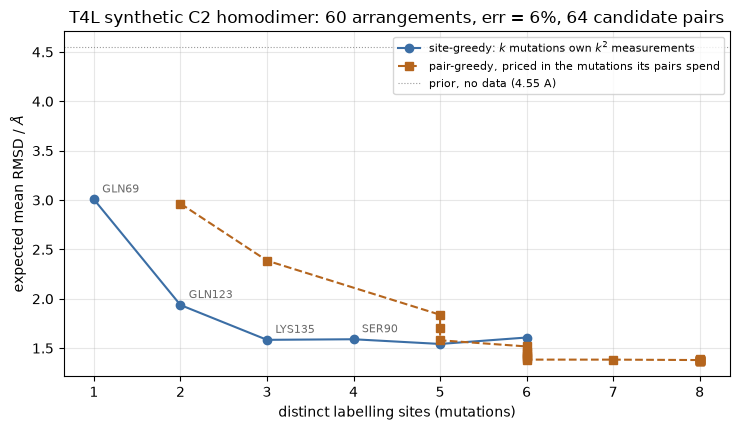

In [7]:
\
fig, ax = plt.subplots(figsize=(7.5, 4.4))
k = np.arange(1, len(site_decay) + 1)
ax.plot(k, site_decay, "o-", color="#3b6ea5",
        label="site-greedy: $k$ mutations own $k^2$ measurements")
ax.plot(union, pair_decay[:len(union)], "s--", color="#b5651d",
        label="pair-greedy, priced in the mutations its pairs spend")
ax.axhline(start, color="0.6", lw=0.8, ls=":", label=f"prior, no data ({start:.2f} A)")
for rank, s in enumerate(sel_sites[:4], start=1):
    ax.annotate(f"{resname[sites[s]]}{sites[s]}", (rank, site_decay[rank - 1]),
                textcoords="offset points", xytext=(6, 5), fontsize=8,
                color="dimgray")
ax.set_xlabel("distinct labelling sites (mutations)")
ax.set_ylabel("expected mean RMSD / $\\AA$")
ax.set_title(f"T4L synthetic C2 homodimer: {N_FRAMES} arrangements, "
             f"err = {ERR:.0%}, {len(pair_names)} candidate pairs")
ax.legend(fontsize=8, loc="upper right")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("labelizer_greedy_homodimer.png", dpi=150)
plt.show()

## 7. Trimers, tetramers, and what does not change

The kernel is agnostic to the oligomer order — `pair_sites` *is* the model of
it. A trimer offers, per site pair, the protomer pairs A:B, A:C, B:C (both
orientations each, plus three homotypics per site); a tetramer six protomer
pairs; a C$n$-symmetric assembly collapses some of those columns onto each
other only while it *is* symmetric, as the reference frame above shows. The
selection arithmetic — score a candidate site by every pair the enlarged set
implies — is the same code path throughout, and the monomer remains what it
always was: the special case where every site owns exactly one pair, in which
`select_informative_sites` and `select_informative_pairs` agree exactly (and
are pinned to, in `test/restraints/test_greedy_sites.py`).

One honest caveat, inherited from Olga whole: greedy takes the locally best
site and never revisits. A site whose combinations only pay off two mutations
later — no homotypic signal, weak first pairs — can be passed over early even
though the set containing it is the best final experiment. The decay curve is
the guard: where it flattens, buying another mutation has stopped paying.